## [demo] aggregate the count matrices over metacells

- SEACElls.core.summarize_by_SEACell(ad, SEACells_label="SEACell", celltype_label=None, summarize_layer="raw")

- We will turn this notebook into a function so that we can call from a module

In [1]:
# import libraries
import numpy as np
import scipy.sparse as sp
import pandas as pd
import scanpy as sc
import SEACells
import os

# plotting modules
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import InsetPosition

In [3]:
import sys
sys.path.append("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/scripts/SEACells_metacell/")
from module_compute_seacells import * # import all functions

In [4]:
# Some plotting aesthetics
%matplotlib inline
sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 300

In [5]:
# import logging

# # Set the logging level to WARN, filtering out informational messages
# logging.getLogger().setLevel(logging.WARNING)

# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# # Set the default font to Arial
# mpl.rcParams['font.family'] = 'Arial'

# # If Arial is not available on your system, you might need to specify an alternative or ensure Arial is installed.
# # On some systems, you might need to use 'font.sans-serif' as a fallback option:
# # mpl.rcParams['font.sans-serif'] = 'Arial'

# # Editable text and proper LaTeX fonts in illustrator
# # matplotlib.rcParams['ps.useafm'] = True
# # Editable fonts. 42 is the magic number for editable text in PDFs
# mpl.rcParams['pdf.fonttype'] = 42
# sns.set(style='whitegrid', context='paper')

# # Plotting style function (run this before plotting the final figure)
# def set_plotting_style():
#     plt.style.use('seaborn-paper')
#     plt.rc('axes', labelsize=12)
#     plt.rc('axes', titlesize=12)
#     plt.rc('xtick', labelsize=10)
#     plt.rc('ytick', labelsize=10)
#     plt.rc('legend', fontsize=10)
#     plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
#     plt.rc('xtick.major', pad=2)
#     plt.rc('ytick.major', pad=2)
#     plt.rc('mathtext', fontset='stixsans', sf='sansserif')
#     plt.rc('figure', figsize=[10,9])
#     plt.rc('svg', fonttype='none')

#     # Override any previously set font settings to ensure Arial is used
#     plt.rc('font', family='Arial')

### start with one object, then make a for loop

In [5]:
#plot_2D_modified arguments (filepaths, dim.reduction, annotation, etc.)
input_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/05_SEACells_processed/objects_75cells_per_metacell_integrated_lsi/"
output_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/05_SEACells_processed/objects_30cells_per_metacell/"
data_id = "" # this will be looped into the for loop
annotation_class = "annotation_ML_coarse"
dim_reduction = "X_lsi"
#figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/seacells_individual_datasets_30cells/"
#os.makedirs(figpath, exist_ok=True)
# add the n_cells (for the number of cells per SEACells)
n_cells = 30

In [6]:
# the list of datasets
list_datasets = ["TDR126","TDR127","TDR128",
                 "TDR118reseq","TDR119reseq","TDR125reseq","TDR124reseq"]


In [ ]:
def aggregate_counts_multiome(adata_rna, adata_atac):
    """
    This function aggregates counts over SEACells
    """
    # Aggregate counts over SEACells
    SEACell_ad = SEACells.aggregate_counts(adata, groupby=groupby)
    # Add celltype information
    SEACell_ad.obs["celltype"] = celltype
    # Add the aggregated counts to the original adata object
    adata.obs["SEACell"] = SEACell_ad.obs["SEACell"]
    adata.obs["celltype"] = celltype
    return adata, SEACell_ad

## NOTES

The correlation between RNA and ATAC (gene.activity) was computed by the following steps:

- 1) import integrated RNA/ATAC objects, respectively (ATAC has gene.activity)
- 2) subset for each timepoint, import the SEACell information (metacells), then aggregate the counts (RNA/gene.activity)
- 3) compute the pearson correlation coefficients between 

## Step 1. Load the datasets and preprocess them

In [ ]:
# Load the RNA and ATAC(gene.activity) master object, then subset for each timepoint/dataset
filepath = '/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/'

# RNA master object (all timepoints/datasets)
adata_RNA = sc.read_h5ad(filepath + "integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
print(adata_RNA)

# ATAC (gene.acitivitiy) master object (all timepoints/datasets)
adata_ATAC = sc.read_h5ad(filepath + "integrated_RNA_ATAC_counts_gene_activity_raw_counts_master_filtered.h5ad")
print(adata_ATAC)

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'
AnnData object with n_obs × n_

In [5]:
adata_rna = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
adata_rna

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [6]:
adata_atac = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_gene_activity_raw_counts_master_filtered.h5ad")
adata_atac

AnnData object with n_obs × n_vars = 94562 × 25032
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters'
    var: 'features'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [10]:
adata_atac.obs_names.map(adata_rna.obs["annotation_ML_coarse"])

CategoricalIndex(['epidermis', 'pronephros', 'hindbrain', 'spinal_cord',
                  'neural_optic', 'neural_floor_plate', 'neural_crest', 'PSM',
                  'optic_cup', 'neural_optic',
                  ...
                  'epidermis', 'hematopoietic_vasculature', 'somites',
                  'endocrine_pancreas', 'hemangioblasts', 'tail_bud',
                  'lateral_plate_mesoderm', 'neural_posterior',
                  'endocrine_pancreas', 'somites'],
                 categories=['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', ..., 'pronephros', 'somites', 'spinal_cord', 'tail_bud'], ordered=False, dtype='category', length=94562)

In [11]:
# transfer some annotations
adata_atac.obs["annotation_ML_coarse"] = adata_atac.obs_names.map(adata_rna.obs["annotation_ML_coarse"])
adata_atac.uns['annotation_ML_coarse_colors'] = adata_rna.uns['annotation_ML_coarse_colors']


### test with one dataset

In [16]:
filepath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/"

# subset for individual dataset, and edit the adata.obs_names (to remove the extract "XXX_1")
data_id = "TDR118reseq"
sample_id = data_id.replace("reseq","")

# subset for each "dataset"
rna_ad = adata_rna[adata_rna.obs.dataset==sample_id]
atac_ad = adata_atac[adata_atac.obs.dataset==sample_id]

# reformat the adata.obs_names (to remove the additional index from f"XXXX_{index}")
rna_ad.obs_names = rna_ad.obs_names.str.rsplit('_', n=1).str[0]
rna_ad.obs_names

atac_ad.obs_names = atac_ad.obs_names.str.rsplit('_', n=1).str[0]
atac_ad.obs_names

# import the individual ATAC data to copy "X_lsi" ("X_svd") in adata.obsm field
# since SEACell aggregation requires "X_svd" embedding, we will add it (it's basically the same as X_lsi in our pipeline)
lsi = pd.read_csv(fiblepath + f"{data_id}/{sample_id}_lsi.csv", index_col=0)
lsi = lsi[lsi.index.isin(atac_ad.obs_names)]
atac_ad.obsm["X_svd"] = lsi.values

# make sure that the "adata.X" is the raw counts
rna_ad.X = rna_ad.layers["counts"].copy()
atac_ad.X = atac_ad.layers["counts"].copy()

print(rna_ad)
print(atac_ad)

AnnData object with n_obs × n_vars = 13568 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'
AnnData object with n_obs × n_

/home/yang-joon.kim/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/yang-joon.kim/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


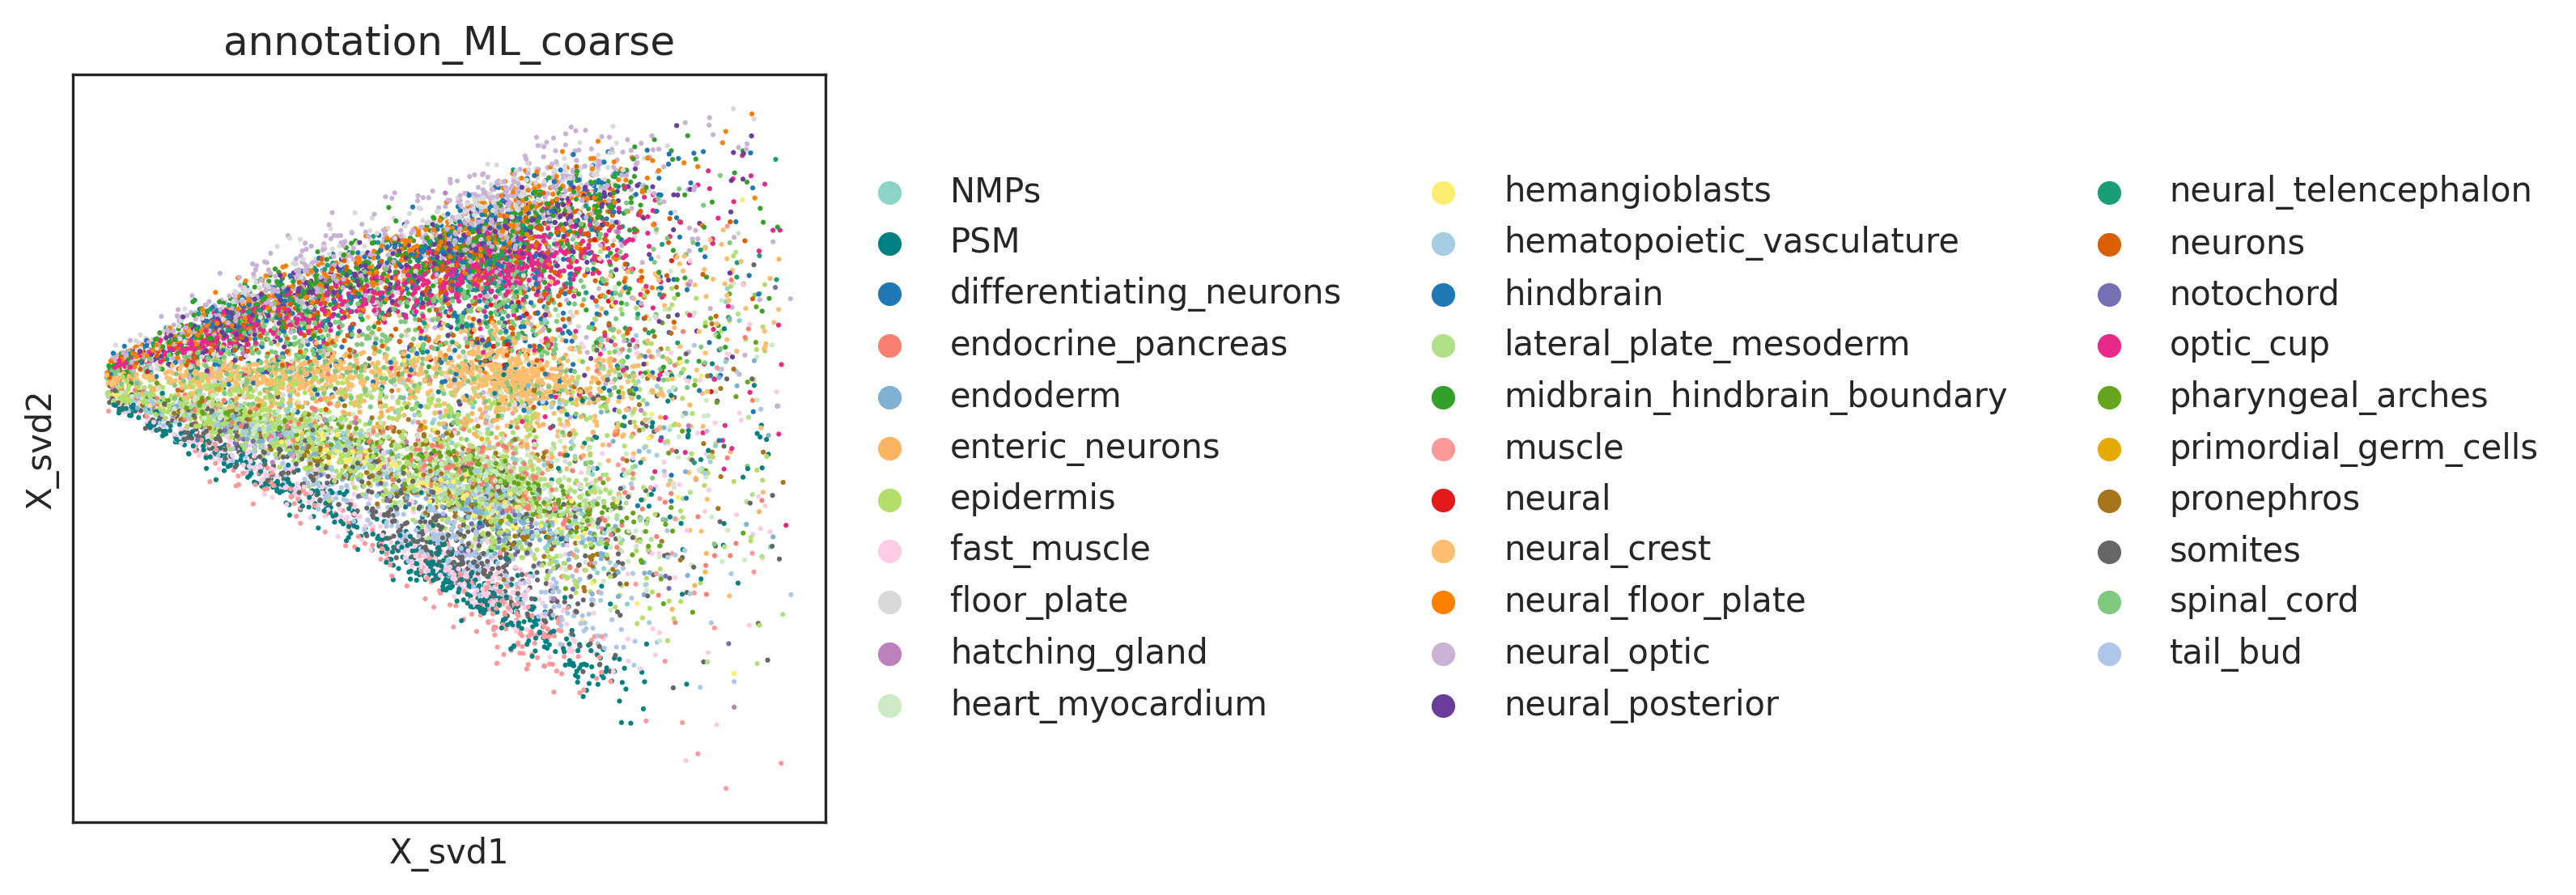

In [17]:
sc.pl.embedding(atac_ad, basis="X_svd", color="annotation_ML_coarse")

In [18]:
rna_ad.var_names.intersection(atac_ad.var_names)

Index(['ptpn12', 'phtf2', 'phtf2.1', 'CU856344.1', 'si:zfos-932h1.3', 'mansc1',
       'lrp6', 'dusp16', 'crebl2', 'gpr19',
       ...
       'mt-co2', 'mt-atp8', 'mt-atp6', 'mt-co3', 'mt-nd3', 'mt-nd4l', 'mt-nd4',
       'mt-nd5', 'mt-nd6', 'mt-cyb'],
      dtype='object', length=25031)

In [231]:
# Load the SEACells (adata.obs)
seacellpath = '/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/05_SEACells_processed/objects_30cells_per_metacell/'
# data_id = "TDR118reseq"
# sample_id = data_id.replace("reseq","")

# import the seacell metadata (dataframe)
df_seacells = pd.read_csv(seacellpath + f"{sample_id}_seacells.csv", index_col=0)
df_seacells

# create a dictionary of {"cell_id":"SEACell"}
dict_seacells = df_seacells["SEACell"].to_dict()

# transfer the "SEACell" information to the RNA and ATAC adata objects
rna_ad.obs["SEACell"] = rna_ad.obs_names.map(dict_seacells)
atac_ad.obs["SEACell"] = atac_ad.obs_names.map(dict_seacells)

In [78]:
rna_ad.X.todense()

matrix([[ 0.,  0.,  0., ..., 17.,  0.,  0.],
        [ 0.,  0.,  0., ..., 37.,  0.,  0.],
        [ 0.,  0.,  0., ..., 62.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ..., 13.,  0.,  0.],
        [ 0.,  0.,  0., ..., 21.,  0.,  0.],
        [ 0.,  0.,  0., ..., 29.,  0.,  0.]])

In [79]:
atac_ad.X.todense()

matrix([[ 0,  0,  0, ..., 42, 22, 38],
        [ 0,  0,  0, ..., 29,  7, 19],
        [ 0,  0,  0, ..., 32, 13, 24],
        ...,
        [ 0,  1,  0, ..., 33, 18, 31],
        [ 0,  0,  0, ...,  4,  4,  6],
        [ 0,  0,  0, ..., 17,  8, 10]])

In [232]:
# add a placeholder value of 0.5 for atac_ad_seacells.var["GC"] field 
# this is for SEACElls operations
atac_ad.var["GC"] = 0.5
atac_ad.var["GC"]

ptpn12             0.5
phtf2              0.5
phtf2.1            0.5
CU856344.1         0.5
si:zfos-932h1.3    0.5
                  ... 
mt-nd4l            0.5
mt-nd4             0.5
mt-nd5             0.5
mt-nd6             0.5
mt-cyb             0.5
Name: GC, Length: 25032, dtype: float64

In [43]:
# # Compute the GC content of peaks for SEACells
# # SEACells.genescore.prepare_multiome_anndata()
# # source: https://github.com/dpeerlab/SEACells/issues/12

# import numpy as np
# import anndata as ad

# import genomepy
# from Bio.SeqUtils import gc_fraction

# # inputs:
# # 1) adata_atac: anndata for the scATAC-seq (cells-by-peaks)
# # output:
# def compute_GC_contents_scATAC(adata_atac, genome_name, provider):

#     # download genome from NCBI
#     genome_name = "GRCz11"
#     provider = "Ensembl"
#     genomepy.install_genome(name=genome_name, provider=provider, genome_dir = "../data")
#     genome = genomepy.Genome(name=genome_name, genome_dir="../data")
#     #genomepy.install_genome(name='GRCh38', provider='NCBI', genomes_dir = ''../data') # took about 9 min
#     #genome = genomepy.Genome(name = 'GRCh38', genomes_dir = '../data')

#     GC_content_list = []

#     for i, region in enumerate(adata_atac.var_names):
#         chromosome, start, end = region.split('-')
#         chromosome = chromosome[3:]

#         # get sequence
#         sequence = str(genome.get_seq(name = chromosome, start = int(start), end = int(end)))

#         # calculate GC content
#         GC_content = gc_fraction(str(sequence))
#         GC_content_list.append(GC_content)

#     # GC content ranges from 0% - 100%, should be 0 to 1
#     adata_atac.var['GC'] = GC_content_list
#     adata_atac.var.GC = adata_atac.var.GC/100

#     return adata_atac

In [42]:
# # To find the right genome name and provider
# for provided_genome in genomepy.search('GRCz11', provider=None):
#    print(provided_genome)

# # result:
# # ['GRCz11', 'Ensembl', 'GCA_000002035.4', 7955, True, 'Danio rerio', '2017-08-Ensembl/2018-04']
# # ['danRer11', 'UCSC', 'GCA_000002035.4', 7955, [True, True, True, False], 'Danio rerio', 'May 2017 (GRCz11/danRer11)']

In [52]:
# atac_ad_seacells = compute_GC_contents_scATAC(atac_ad_seacells, "GRCz11", "Ensembl")


# Preparation step


In the first step, we derive summarized ATAC and RNA SEACell metacells Anndata objects. Both the input single-cell RNA and ATAC anndata objects should contain raw, unnormalized data. SEACell results on ATAC data will be used for the summarization

<b>Warning: </b> The ATAC and RNA single-cell Anndata objects should contain the same set of cells. Only the common cells will be used for downstream analyses.

In [241]:
print(rna_ad.shape[1])
print(atac_ad.shape[1])

32057
25032


In [244]:
atac_ad

AnnData object with n_obs × n_vars = 13568 × 25032
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'annotation_ML_coarse', 'SEACell'
    var: 'features', 'GC'
    uns: 'annotation_ML_coarse_colors'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap', 'X_svd'
    layers: 'counts'

In [245]:
atac_meta_ad, rna_meta_ad = SEACells.genescores.prepare_multiome_anndata(atac_ad, rna_ad, SEACells_label='SEACell')

Generating Metacell matrices...
 ATAC


100%|██████████| 181/181 [00:00<00:00, 240.15it/s]
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACells-0.3.3-py3.8.egg/SEACells/genescores.py:77: RuntimeWarning: divide by zero encountered in log10
  atac_ad.var['log_n_counts'] = np.ravel(np.log10(atac_ad.X.sum(axis=0)))
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACells-0.3.3-py3.8.egg/SEACells/genescores.py:77: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  atac_ad.var['log_n_counts'] = np.ravel(np.log10(atac_ad.X.sum(axis=0)))
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/numpy/core/function_base.py:157: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/numpy/core/function_base.py:167: RuntimeWarning: invalid value encountered in add
  y += start
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACe

 RNA


100%|██████████| 181/181 [00:00<00:00, 252.46it/s]


The preparation step will generate summarized anndata objects for RNA and ATAC

In [246]:
atac_meta_ad

AnnData object with n_obs × n_vars = 181 × 24924
    obs: 'n_counts'
    var: 'GC_bin', 'counts_bin', 'n_cells'
    uns: 'log1p'
    obsm: 'X_svd'
    layers: 'raw'

In [247]:
rna_meta_ad

AnnData object with n_obs × n_vars = 181 × 32057
    obs: 'n_counts'
    uns: 'log1p'
    layers: 'raw'

### summary

rna_meta_ad, and atac_meta_ad are "aggregated" across metacells (SEACell), and the raw counts were saved in "adata.raw" slot, and the adata.X contains log-normalized (using sc.pp.normalize_total, which takes the median # of UMIs/cell across all cells in that dataset as the denominator).

In [93]:
sample_id

'TDR118'

In [94]:
# save the aggregated adata objects
atac_meta_ad.write_h5ad(seacellpath + f"{data_id}/{sample_id}_ATAC_seacells_aggre.h5ad")
rna_meta_ad.write_h5ad(seacellpath + f"{data_id}/{sample_id}_RNA_seacells_aggre.h5ad")

## make a for loop to aggreage the count matrices for each modality (rna, atac)

- save the aggregated counts into metacells-by-features objects (rna_meta_ad, atac_meta_ad), with the cell-type annotation for metacell.

In [20]:
# reset the colors
# a color palette for the "coarse" grained celltype annotation ("annotation_ML_coarse")
cell_type_color_dict = {
    'NMPs': '#8dd3c7',
    'PSM': '#008080',
    'differentiating_neurons': '#bebada',
    'endocrine_pancreas': '#fb8072',
    'endoderm': '#80b1d3',
    'enteric_neurons': '#fdb462',
    'epidermis': '#b3de69',
    'fast_muscle': '#df4b9b',
    'floor_plate': '#d9d9d9',
    'hatching_gland': '#bc80bd',
    'heart_myocardium': '#ccebc5',
    'hemangioblasts': '#ffed6f',
    'hematopoietic_vasculature': '#e41a1c',
    'hindbrain': '#377eb8',
    'lateral_plate_mesoderm': '#4daf4a',
    'midbrain_hindbrain_boundary': '#984ea3',
    'muscle': '#ff7f00',
    'neural': '#e6ab02',
    'neural_crest': '#a65628',
    'neural_floor_plate': '#66a61e',
    'neural_optic': '#999999',
    'neural_posterior': '#393b7f',
    'neural_telencephalon': '#fdcdac',
    'neurons': '#cbd5e8',
    'notochord': '#f4cae4',
    'optic_cup': '#c0c000',
    'pharyngeal_arches': '#fff2ae',
    'primordial_germ_cells': '#f1e2cc',
    'pronephros': '#cccccc',
    'somites': '#1b9e77',
    'spinal_cord': '#d95f02',
    'tail_bud': '#7570b3'
}

In [21]:
def compute_prevalent_celltype_per_metacell(adata, celltype_key="annotation_ML_coarse", metacell_key="SEACell"):
    """
    Compute the most prevalent cell type in each metacell.
    
    :param adata: AnnData object containing the cell type and metacell information in .obs.
    :param celltype_key: (str) Key in adata.obs for cell types (e.g., 'annotation_ML_coarse').
    :param metacell_key: (str) Key in adata.obs for metacells (e.g., 'SEACell').
    :return: A pandas Series where the index is the metacell and the value is the most prevalent cell type.
    """
    
    # Extract the relevant columns from adata.obs
    df = adata.obs[[celltype_key, metacell_key]].copy()

    # Group by metacell and count occurrences of each cell type
    prevalent_celltypes = df.groupby(metacell_key)[celltype_key] \
                            .apply(lambda x: x.value_counts().idxmax())
    
    return prevalent_celltypes

In [27]:
filepath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/"

output_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/05_SEACells_processed/objects_30cells_per_metacell/aggregated_counts/"
os.makedirs(output_path, exist_ok=True)

# Load the SEACells (adata.obs)
seacellpath = '/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/05_SEACells_processed/objects_30cells_per_metacell/'


In [24]:
# define the list of datasets
list_datasets = ["TDR126","TDR127","TDR128","TDR118reseq","TDR125reseq","TDR124reseq"]

In [35]:
for data_id in list_datasets:
    # subset for individual dataset, and edit the adata.obs_names (to remove the extract "XXX_1")
    # data_id = "TDR118reseq"
    sample_id = data_id.replace("reseq","")

    # subset for each "dataset"
    rna_ad = adata_rna[adata_rna.obs.dataset==sample_id]
    atac_ad = adata_atac[adata_atac.obs.dataset==sample_id]

    # reformat the adata.obs_names (to remove the additional index from f"XXXX_{index}")
    rna_ad.obs_names = rna_ad.obs_names.str.rsplit('_', n=1).str[0]
    rna_ad.obs_names

    atac_ad.obs_names = atac_ad.obs_names.str.rsplit('_', n=1).str[0]
    atac_ad.obs_names

    # import the individual ATAC data to copy "X_lsi" ("X_svd") in adata.obsm field
    # since SEACell aggregation requires "X_svd" embedding, we will add it (it's basically the same as X_lsi in our pipeline)
    lsi = pd.read_csv(filepath + f"{data_id}/{sample_id}_lsi.csv", index_col=0)
    lsi = lsi[lsi.index.isin(atac_ad.obs_names)]
    atac_ad.obsm["X_svd"] = lsi.values

    # make sure that the "adata.X" is the raw counts
    rna_ad.X = rna_ad.layers["counts"].copy()
    atac_ad.X = atac_ad.layers["counts"].copy()

    print(rna_ad)
    print(atac_ad)

    # import the seacell metadata (dataframe)
    df_seacells = pd.read_csv(seacellpath + f"{sample_id}_seacells.csv", index_col=0)
    df_seacells

    # create a dictionary of {"cell_id":"SEACell"}
    dict_seacells = df_seacells["SEACell"].to_dict()

    # transfer the "SEACell" information to the RNA and ATAC adata objects
    rna_ad.obs["SEACell"] = rna_ad.obs_names.map(dict_seacells)
    atac_ad.obs["SEACell"] = atac_ad.obs_names.map(dict_seacells)

    # add a placeholder value of 0.5 for atac_ad_seacells.var["GC"] field 
    # this is for SEACElls operations
    atac_ad.var["GC"] = 0.5
    atac_ad.var["GC"]

    # aggregate the raw counts (saves the normalized counts in the .X layer, and saves the "raw" layer for the raw counts for each metacell
    atac_meta_ad, rna_meta_ad = SEACells.genescores.prepare_multiome_anndata(atac_ad, rna_ad, SEACells_label='SEACell')

    # copy over the most prevalent celltype annotations
    prevalent_celltypes = compute_prevalent_celltype_per_metacell(rna_ad, celltype_key="annotation_ML_coarse", 
                                                                  metacell_key="SEACell")

    # Add the most prevalent cell type to the metacell dataframe
    atac_meta_ad.obs["celltype"] = atac_meta_ad.obs_names.map(prevalent_celltypes)
    rna_meta_ad.obs["celltype"] = rna_meta_ad.obs_names.map(prevalent_celltypes)

    # save the metacell-aggregated adata objects
    atac_meta_ad.write_h5ad(output_path + f"{sample_id}_atac_meta.h5ad")
    rna_meta_ad.write_h5ad(output_path + f"{sample_id}_rna_meta.h5ad")

AnnData object with n_obs × n_vars = 14970 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'
AnnData object with n_obs × n_

100%|██████████| 499/499 [00:01<00:00, 292.19it/s]
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACells-0.3.3-py3.8.egg/SEACells/genescores.py:77: RuntimeWarning: divide by zero encountered in log10
  atac_ad.var['log_n_counts'] = np.ravel(np.log10(atac_ad.X.sum(axis=0)))
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACells-0.3.3-py3.8.egg/SEACells/genescores.py:77: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  atac_ad.var['log_n_counts'] = np.ravel(np.log10(atac_ad.X.sum(axis=0)))
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/numpy/core/function_base.py:157: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/numpy/core/function_base.py:167: RuntimeWarning: invalid value encountered in add
  y += start
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACe

 RNA


100%|██████████| 499/499 [00:02<00:00, 224.67it/s]


AnnData object with n_obs × n_vars = 18963 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'
AnnData object with n_obs × n_

...

/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACells-0.3.3-py3.8.egg/SEACells/genescores.py:58: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  rna_mod_ad.obs['temp'] = atac_mod_ad.obs[SEACells_label]
100%|██████████| 571/571 [00:02<00:00, 254.34it/s]


AnnData object with n_obs × n_vars = 6528 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'
AnnData object with n_obs × n_v

100%|██████████| 217/217 [00:00<00:00, 381.36it/s]
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACells-0.3.3-py3.8.egg/SEACells/genescores.py:77: RuntimeWarning: divide by zero encountered in log10
  atac_ad.var['log_n_counts'] = np.ravel(np.log10(atac_ad.X.sum(axis=0)))
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACells-0.3.3-py3.8.egg/SEACells/genescores.py:77: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  atac_ad.var['log_n_counts'] = np.ravel(np.log10(atac_ad.X.sum(axis=0)))
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/numpy/core/function_base.py:157: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/numpy/core/function_base.py:167: RuntimeWarning: invalid value encountered in add
  y += start
/home/yang-joon.kim/.conda/envs/seacells/lib/python3.8/site-packages/SEACe

 RNA


100%|██████████| 217/217 [00:00<00:00, 308.50it/s]


In [36]:
rna_meta_ad

AnnData object with n_obs × n_vars = 217 × 32057
    obs: 'n_counts', 'celltype'
    uns: 'log1p'
    layers: 'raw'

In [37]:
atac_meta_ad

AnnData object with n_obs × n_vars = 217 × 24890
    obs: 'n_counts', 'celltype'
    var: 'GC_bin', 'counts_bin', 'n_cells'
    uns: 'log1p'
    obsm: 'X_svd'
    layers: 'raw'